# Predicción del Precio de Vivienda en King County - Análisis Exploratorio de Datos

In [ ]:
import numpy as npimport pandas as pdimport matplotlib.pyplot as pltimport seaborn as sns

## 1. Carga de Datos

In [ ]:
import kagglehubfrom pathlib import Pathpath = kagglehub.dataset_download("harlfoxem/housesalesprediction")csv_path = Path(path) / "kc_house_data.csv"print("Dataset downloaded to:", csv_path)

Dataset downloaded to: /home/avidaldo/.cache/kagglehub/datasets/harlfoxem/housesalesprediction/versions/1/kc_house_data.csv


In [ ]:
df = pd.read_csv(csv_path)print(f"Dataset shape: {df.shape}")df.head()

Dataset shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## 2. Descripción General de los Datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

### Descripción de las Columnas

| Columna | Descripción | Tipo |
|--------|-------------|------|
| `id` | Identificador de propiedad | Identificador (descartar) |
| `date` | Fecha de venta | Temporal |
| `price` | Precio de venta | **Objetivo** |
| `bedrooms` | Número de habitaciones | Numérico |
| `bathrooms` | Número de baños | Numérico |
| `sqft_living` | Área habitable (pies cuadrados) | Numérico |
| `sqft_lot` | Tamaño del lote (pies cuadrados) | Numérico |
| `floors` | Número de pisos | Numérico |
| `waterfront` | Propiedad con frente al agua (0/1) | Binario |
| `view` | Calificación de la vista (0-4) | Ordinal |
| `condition` | Calificación del estado (1-5) | Ordinal |
| `grade` | Calidad de construcción (1-13) | Ordinal |
| `sqft_above` | Área sobre el nivel del suelo | Numérico |
| `sqft_basement` | Área del sótano | Numérico |
| `yr_built` | Año de construcción | Numérico |
| `yr_renovated` | Año de renovación (0 si nunca) | Numérico |
| `zipcode` | Código ZIP | Categórico (alta cardinalidad) |
| `lat`, `long` | Coordenadas | Geográfico |
| `sqft_living15` | Área habitable promedio de los 15 vecinos más cercanos | Numérico |
| `sqft_lot15` | Tamaño de lote promedio de los 15 vecinos más cercanos | Numérico |

### Formato de la Columna Date
La columna `date` está almacenada como tipo objeto (cadena de texto). Examinemos su formato para entender cómo manejarlo durante el preprocesamiento.

In [ ]:
print("Date column sample values:")print(df["date"].head(10))print(f"\nDate column dtype: {df['date'].dtype}")

Date column sample values:
0    20141013T000000
1    20141209T000000
2    20150225T000000
3    20141209T000000
4    20150218T000000
5    20140512T000000
6    20140627T000000
7    20150115T000000
8    20150415T000000
9    20150312T000000
Name: date, dtype: object

Date column dtype: object


### Decisión de Ingeniería de Características Temporales
El formato de fecha parece ser `YYYYMMDDTHHMMSS`. Durante el preprocesamiento, necesitamos extraer características temporales útiles de esta columna.

**Opción 1: Extraer año y mes (discreto)**
- Podría capturar **estacionalidad** (p. ej., precios más altos en primavera/verano)
- Crea dos características: `sale_year`, `sale_month`
- Problema: Nuestro conjunto de datos abarca solo ~1 año (2014-05 a 2015-05), por lo que no tenemos suficientes datos para estimar de forma confiable los patrones de estacionalidad anual

**Opción 2: Días desde la primera venta (continuo)**
- Captura la **tendencia temporal** en los precios (apreciación/depreciación del mercado a lo largo del tiempo)
- Una sola característica: `days_since_start`
- Preserva el orden lineal del tiempo, importante para modelar el impulso de precios

**Decisión: Usaremos `days_since_start`** (Opción 2) porque:
1. Con solo 1 año de datos, la estacionalidad no puede estimarse de forma confiable
2. Los mercados inmobiliarios suelen mostrar tendencias continuas (precios subiendo o bajando a lo largo de los meses)
3. Una sola característica continua es más simple y evita posibles problemas de codificación
4. La tendencia temporal lineal es más relevante para un modelo de regresión que los patrones cíclicos que no podemos estimar correctamente

### Valores Faltantes

In [ ]:
missing = df.isnull().sum()if missing.sum() == 0:    print("No missing values in the dataset.")else:    print("Missing values:")    print(missing[missing > 0])

No missing values in the dataset.


### Estadísticas Descriptivas

In [ ]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


**Observaciones clave**:
- `price`: Rango amplio (\$75K a \$7.7M), la media > mediana indica sesgo hacia la derecha
- Grandes diferencias entre media y mediana para varias características (p. ej., `sqft_lot`, `sqft_basement`) sugieren distribuciones sesgadas a la derecha
- `bedrooms`: El máximo de 33 es sospechoso (probablemente un valor atípico)
- `sqft_lot`: Máximo muy alto comparado con la mediana — muy sesgado a la derecha
- `yr_renovated`: Muchos ceros (no renovado)

## 3. Variable Objetivo: Price

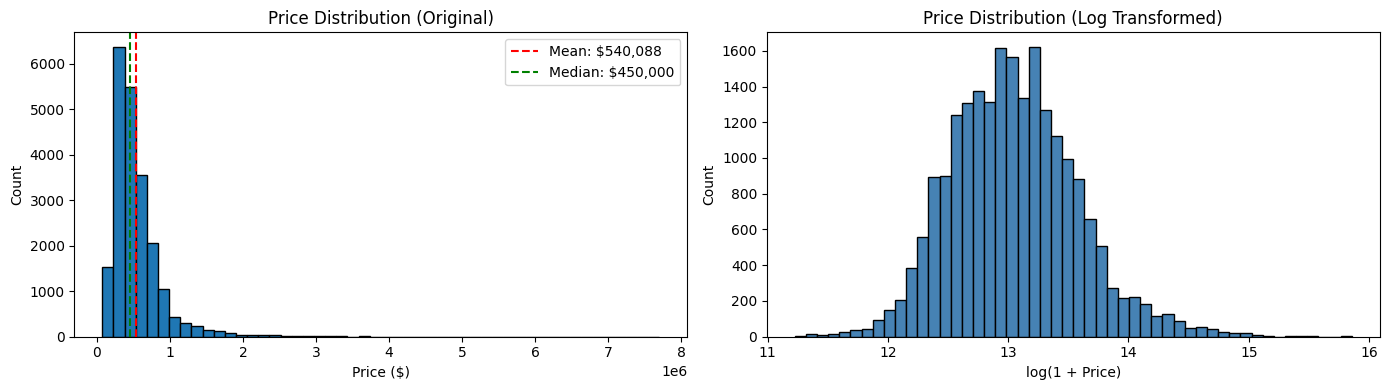

Skewness (original): 4.02
Skewness (log): 0.43


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))# Original distribuciónaxes[0].hist(df["price"], bins=50, edgecolor='black')axes[0].axvline(df["price"].mean(), color='r', linestyle='--', label=f'Mean: ${df["price"].mean():,.0f}')axes[0].axvline(df["price"].median(), color='g', linestyle='--', label=f'Median: ${df["price"].median():,.0f}')axes[0].set_xlabel("Price ($)")axes[0].set_ylabel("Count")axes[0].set_title("Price Distribution (Original)")axes[0].legend()# Log-transformedaxes[1].hist(np.log1p(df["price"]), bins=50, edgecolor='black', color='steelblue')axes[1].set_xlabel("log(1 + Price)")axes[1].set_ylabel("Count")axes[1].set_title("Price Distribution (Log Transformed)")plt.tight_layout()plt.show()print(f"Skewness (original): {df['price'].skew():.2f}")print(f"Skewness (log): {np.log1p(df['price']).skew():.2f}")

**Observación**: La distribución de precios está fuertemente sesgada a la derecha (asimetría positiva), con una larga cola de propiedades costosas. La media es significativamente más alta que la mediana, confirmando esta asimetría.

**Implicación**: Una transformación logarítmica podría ayudar a normalizar esta distribución. Esto es relevante para:
1. Modelos lineales que asumen residuos normalmente distribuidos
2. Características con distribuciones sesgadas similares (p. ej., variables de superficie en pies cuadrados)

Aplicaremos transformaciones logarítmicas durante el preprocesamiento.

**Hallazgo**: El precio tiene un fuerte sesgo a la derecha. La transformación logarítmica reduce significativamente la asimetría. Considera si:
1. Predecir log(price) y transformar de vuelta, o
2. Usar modelos robustos ante objetivos sesgados (p. ej., basados en árboles)

## 4. Análisis Temporal

In [ ]:
# Parse date columnadf["date_parsed"] = pd.to_datetime(df["date"].str[:8], format="%Y%m%d")print(f"Date range: {df['date_parsed'].min().date()} to {df['date_parsed'].max().date()}")print(f"Duration: {(df['date_parsed'].max() - df['date_parsed'].min()).days} days")

Date range: 2014-05-02 to 2015-05-27
Duration: 390 days


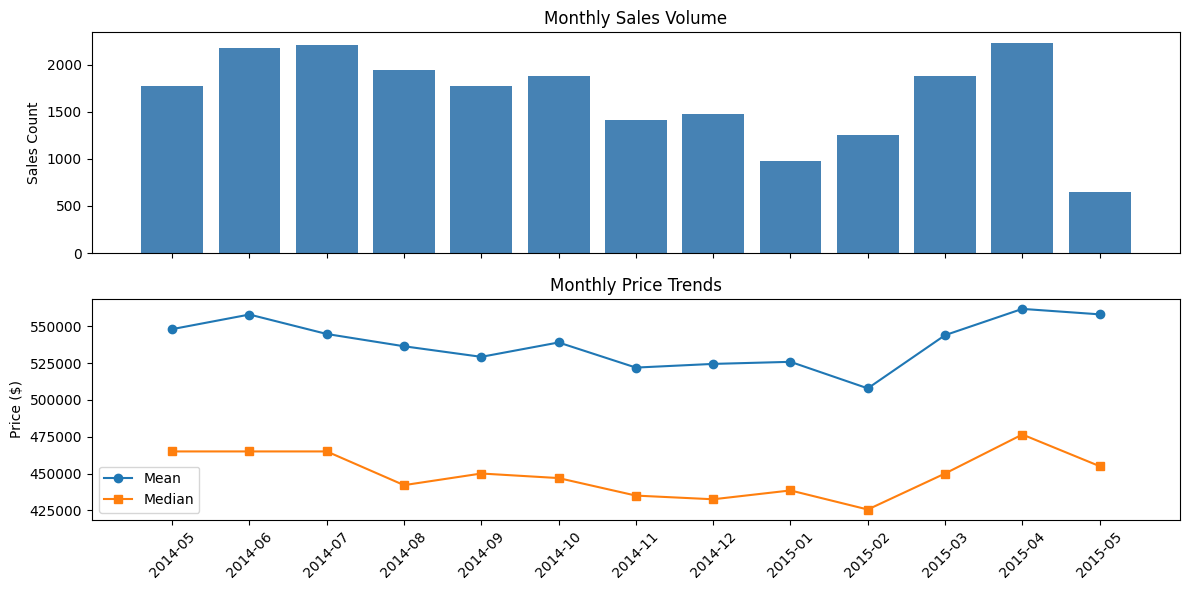

In [ ]:
# Monthly patternsdf["year_month"] = df["date_parsed"].dt.to_period("M")monthly = df.groupby("year_month").agg(    count=("price", "count"),    mean_price=("price", "mean"),    median_price=("price", "median"))fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)axes[0].bar(range(len(monthly)), monthly["count"], color="steelblue")axes[0].set_ylabel("Sales Count")axes[0].set_title("Monthly Sales Volume")axes[1].plot(range(len(monthly)), monthly["mean_price"], marker="o", label="Mean")axes[1].plot(range(len(monthly)), monthly["median_price"], marker="s", label="Median")axes[1].set_ylabel("Price ($)")axes[1].set_title("Monthly Price Trends")axes[1].set_xticks(range(len(monthly)))axes[1].set_xticklabels([str(p) for p in monthly.index], rotation=45)axes[1].legend()plt.tight_layout()plt.show()

## 5. Distribuciones de las Características

### 5.1 Características Discretas/Ordinales

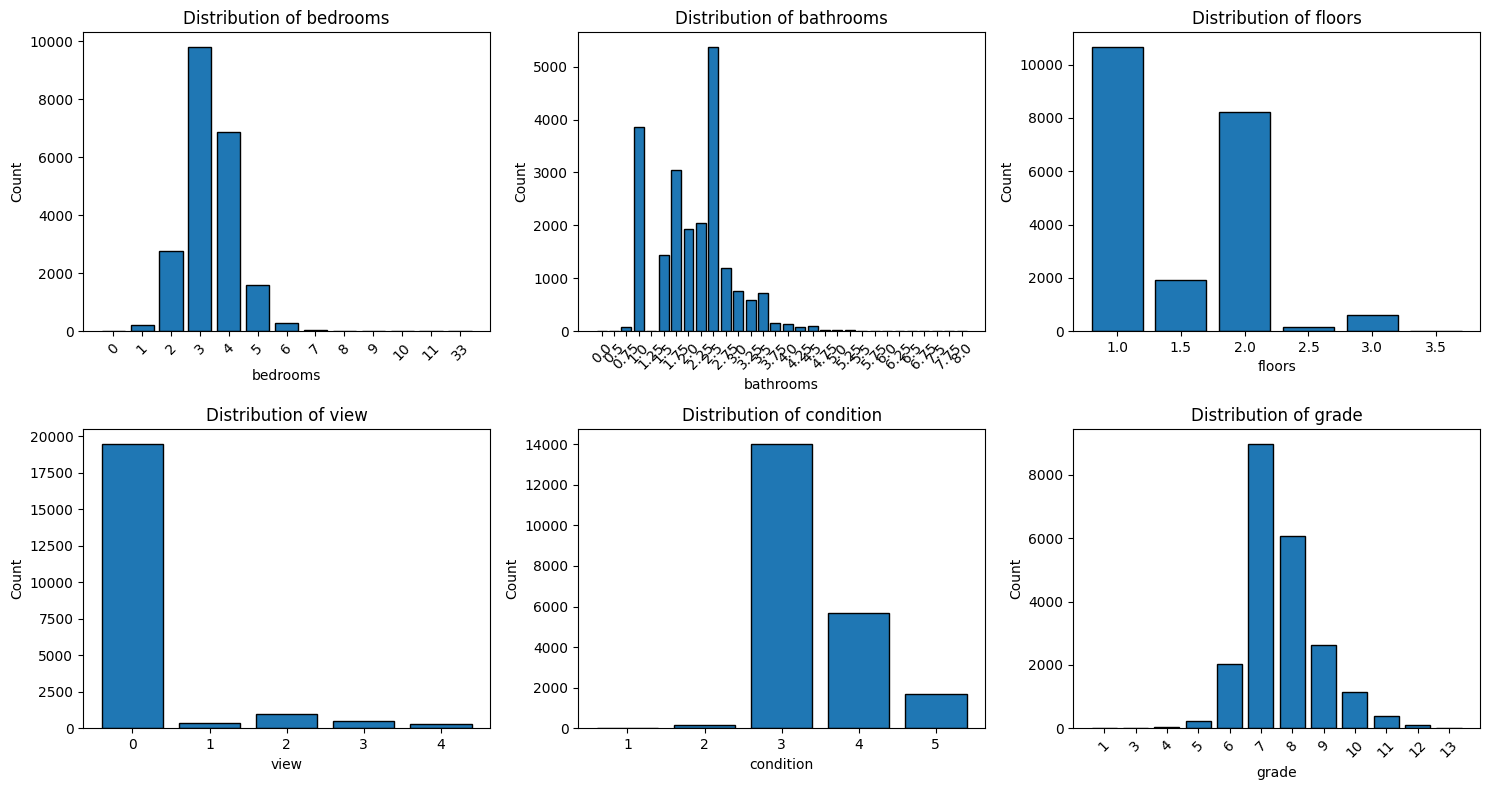

In [ ]:
discrete_features = ["bedrooms", "bathrooms", "floors", "view", "condition", "grade"]fig, axes = plt.subplots(2, 3, figsize=(15, 8))axes = axes.flatten()for ax, col in zip(axes, discrete_features):    counts = df[col].value_counts().sort_index()    ax.bar(counts.index.astype(str), counts.values, edgecolor='black')    ax.set_xlabel(col)    ax.set_ylabel("Count")    ax.set_title(f"Distribution of {col}")    if len(counts) > 10:        ax.tick_params(axis='x', rotation=45)plt.tight_layout()plt.show()

**Observaciones sobre las características discretas:**
- **bedrooms**: La mayoría de las casas tienen 3-4 habitaciones. Hay un valor atípico extremo con 33 habitaciones (probablemente un error de entrada de datos)
- **bathrooms**: Sesgo a la derecha, la mayoría tiene 1-2.5 baños. Los medios baños (incrementos de 0.5) son comunes
- **floors**: Predominantemente 1-2 pisos, con algunas casas de 1.5, 2.5 y 3 pisos
- **view**: Fuertemente desbalanceado — la mayoría de propiedades no tienen vista (0). Esto es esencialmente una característica positiva rara
- **condition**: Distribución aproximadamente normal centrada en 3 (condición promedio)
- **grade**: La mayoría de las casas tienen calificaciones 7-8, con un ligero sesgo a la derecha hacia mayor calidad

### Característica Binaria: Waterfront
La columna `waterfront` es un indicador binario (0 o 1) que representa si la propiedad tiene acceso al frente del agua.

In [ ]:
waterfront_counts = df["waterfront"].value_counts()print(f"Waterfront properties: {waterfront_counts.get(1, 0):,} ({100*waterfront_counts.get(1, 0)/len(df):.2f}%)")print(f"Non-waterfront properties: {waterfront_counts.get(0, 0):,} ({100*waterfront_counts.get(0, 0)/len(df):.2f}%)")

Waterfront properties: 163 (0.75%)
Non-waterfront properties: 21,450 (99.25%)


El acceso al frente del agua es una característica rara pero potencialmente valiosa. Su impacto en el precio se examinará en el análisis de correlación.

### 5.2 Características Continuas (Superficie en Pies Cuadrados)

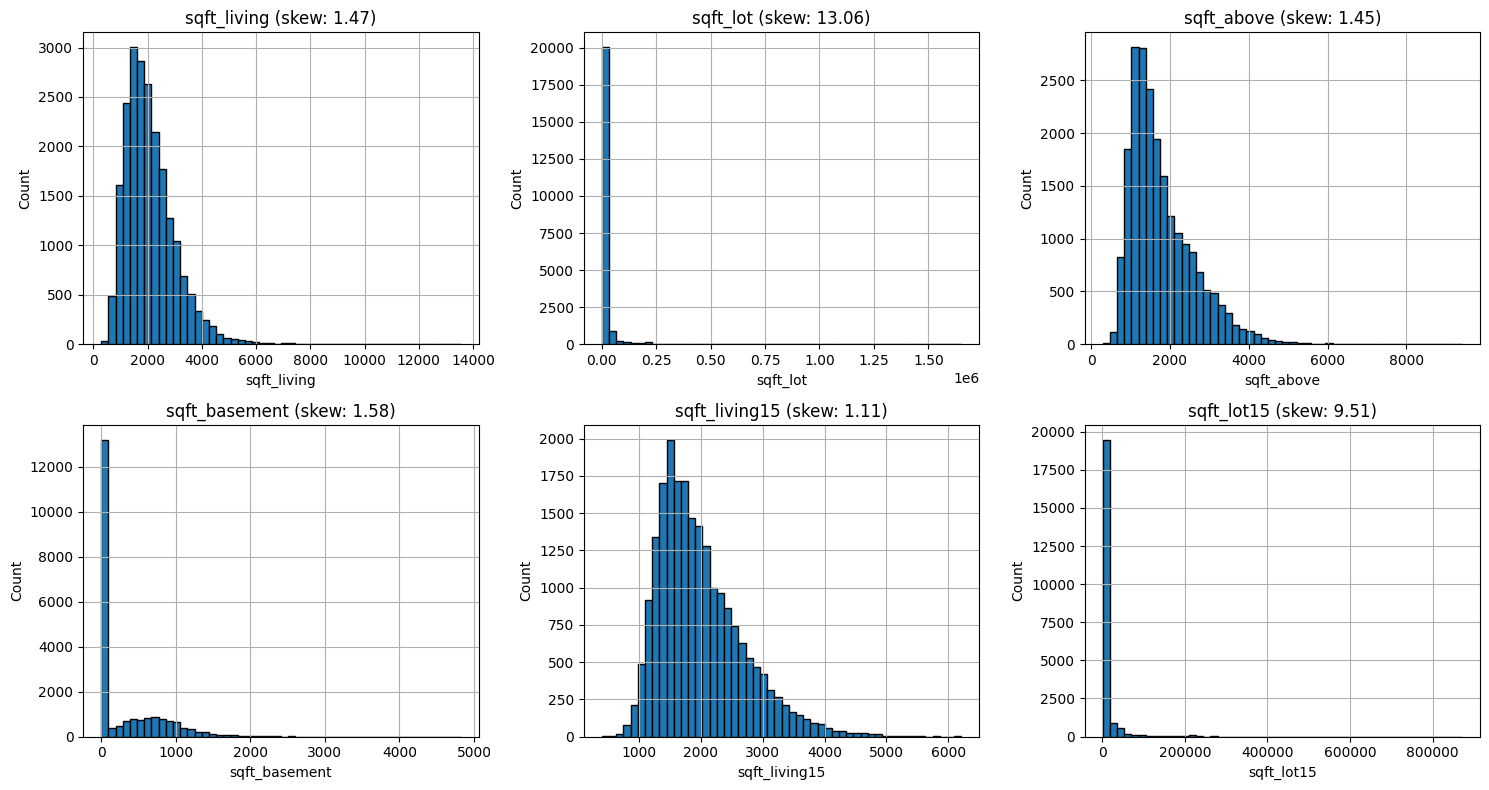

In [ ]:
sqft_features = ["sqft_living", "sqft_lot", "sqft_above", "sqft_basement", "sqft_living15", "sqft_lot15"]fig, axes = plt.subplots(2, 3, figsize=(15, 8))axes = axes.flatten()for ax, col in zip(axes, sqft_features):    df[col].hist(bins=50, ax=ax, edgecolor='black')    ax.set_xlabel(col)    ax.set_ylabel("Count")    skew = df[col].skew()    ax.set_title(f"{col} (skew: {skew:.2f})")plt.tight_layout()plt.show()

**Hallazgo**: Todas las características de superficie en pies cuadrados tienen sesgo a la derecha. Se recomienda la transformación logarítmica para estas características.

### Características Temporales: Año de Construcción y Renovación
Entender cuándo se construyeron y renovaron las casas proporciona contexto sobre la antigüedad del parque inmobiliario y sus actualizaciones.

In [ ]:
# First, let's examine the yr_renovated columna to understand its valoresprint("Year Renovated - Summary Statistics:")print(df["yr_renovated"].describe())print(f"\nUnique values count: {df['yr_renovated'].nunique()}")print(f"\nValue distribution (showing most common):")print(df["yr_renovated"].value_counts().head(10))

Year Renovated - Summary Statistics:
count    21613.000000
mean        84.402258
std        401.679240
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       2015.000000
Name: yr_renovated, dtype: float64

Unique values count: 70

Value distribution (showing most common):
yr_renovated
0       20699
2014       91
2013       37
2003       36
2005       35
2007       35
2000       35
2004       26
1990       25
2006       24
Name: count, dtype: int64


**Interpretación**: La gran mayoría de las casas tiene `yr_renovated = 0`. Como 0 no es un año válido, esto probablemente indica "no renovada" en lugar de un valor faltante. Los valores distintos de cero (que van de 1934 a 2015) representan años reales de renovación. Este es un patrón de codificación común en conjuntos de datos inmobiliarios.

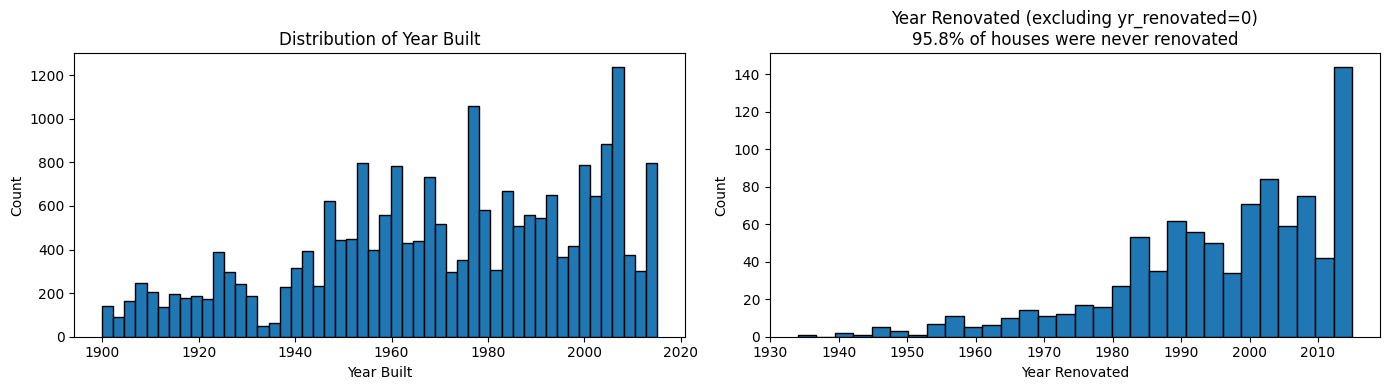

Year built range: 1900 - 2015
Houses with renovation record: 914 (4.2%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))# Year built distribuciónaxes[0].hist(df["yr_built"], bins=50, edgecolor='black')axes[0].set_xlabel("Year Built")axes[0].set_ylabel("Count")axes[0].set_title("Distribution of Year Built")# Year renovated - filtrar out zeros (non-renovated houses) to see actual renovation yearsrenovated = df[df["yr_renovated"] > 0]["yr_renovated"]not_renovated_pct = 100 * (len(df) - len(renovated)) / len(df)axes[1].hist(renovated, bins=30, edgecolor='black')axes[1].set_xlabel("Year Renovated")axes[1].set_ylabel("Count")axes[1].set_title(f"Year Renovated (excluding yr_renovated=0)\n{not_renovated_pct:.1f}% of houses were never renovated")plt.tight_layout()plt.show()print(f"Year built range: {df['yr_built'].min()} - {df['yr_built'].max()}")print(f"Houses with renovation record: {len(renovated):,} ({100*len(renovated)/len(df):.1f}%)")

**Observaciones:**
- **Año de construcción**: Las casas abarcan de 1900 a 2015. Hay mayor actividad de construcción tras los años 40 con picos notables alrededor de los años 60 y 2000
- **Año de renovación**: La mayoría de las casas (>95%) nunca han sido renovadas (yr_renovated = 0). Para las renovadas, la actividad tuvo su pico en los años 2000

**Idea de ingeniería de características**: Crear una característica binaria `is_renovated`, o calcular `years_since_renovation` (usando la fecha de venta).

### Categórico de Alta Cardinalidad: Zipcode
El código ZIP está almacenado como número pero es en realidad categórico. Entendamos su cardinalidad y distribución.

In [ ]:
print(f"Number of unique zipcodes: {df['zipcode'].nunique()}")print(f"\nSales per zipcode (top 10):")print(df["zipcode"].value_counts().head(10))print(f"\nSales per zipcode (bottom 5):")print(df["zipcode"].value_counts().tail(5))

Number of unique zipcodes: 70

Sales per zipcode (top 10):
zipcode
98103    602
98038    590
98115    583
98052    574
98117    553
98042    548
98034    545
98118    508
98023    499
98006    498
Name: count, dtype: int64

Sales per zipcode (bottom 5):
zipcode
98102    105
98010    100
98024     81
98148     57
98039     50
Name: count, dtype: int64


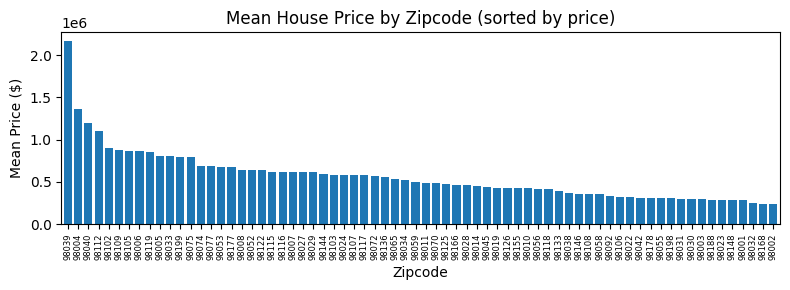


Price range across zipcodes:
  Highest avg price: 98039 ($2,160,607)
  Lowest avg price: 98002 ($234,284)


In [ ]:
# media price by zipcodezipcode_price = df.groupby("zipcode")["price"].mean().sort_values(ascending=False)fig, ax = plt.subplots(figsize=(8, 3))zipcode_price.plot(kind='bar', ax=ax, width=0.8)ax.set_xlabel("Zipcode")ax.set_ylabel("Mean Price ($)")ax.set_title("Mean House Price by Zipcode (sorted by price)")ax.tick_params(axis='x', rotation=90, labelsize=6)plt.tight_layout()plt.show()print(f"\nPrice range across zipcodes:")print(f"  Highest avg price: {zipcode_price.idxmax()} (${zipcode_price.max():,.0f})")print(f"  Lowest avg price: {zipcode_price.idxmin()} (${zipcode_price.min():,.0f})")

**Observaciones:**
- **70 códigos ZIP únicos** — demasiados para codificación one-hot (añadiría 69 características)
- Fuerte variación de precios entre códigos ZIP — la ubicación claramente importa
- Algunos códigos ZIP tienen muy pocas muestras

**Opciones de preprocesamiento:**
1. **Eliminar zipcode**: Usar lat/long en su lugar (continuo, captura la ubicación)
2. **Agrupamiento geográfico**: Agrupar coordenadas en clusters que puedan capturar patrones basados en precio
3. **Conservar para modelos de árbol**: Los modelos basados en árboles pueden manejar categóricos de alta cardinalidad directamente

Como tenemos coordenadas lat/long, nos apoyaremos en el agrupamiento geográfico en lugar de la codificación de códigos ZIP.

## 6. Análisis de Correlación

In [ ]:
# Correlations with pricenumeric_cols = df.select_dtypes(include=[np.number]).columnscorrelations = df[numeric_cols].corr()["price"].sort_values(ascending=False)print("Correlations with price:")print(correlations)

Correlations with price:
price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
id              -0.016762
zipcode         -0.053203
Name: price, dtype: float64


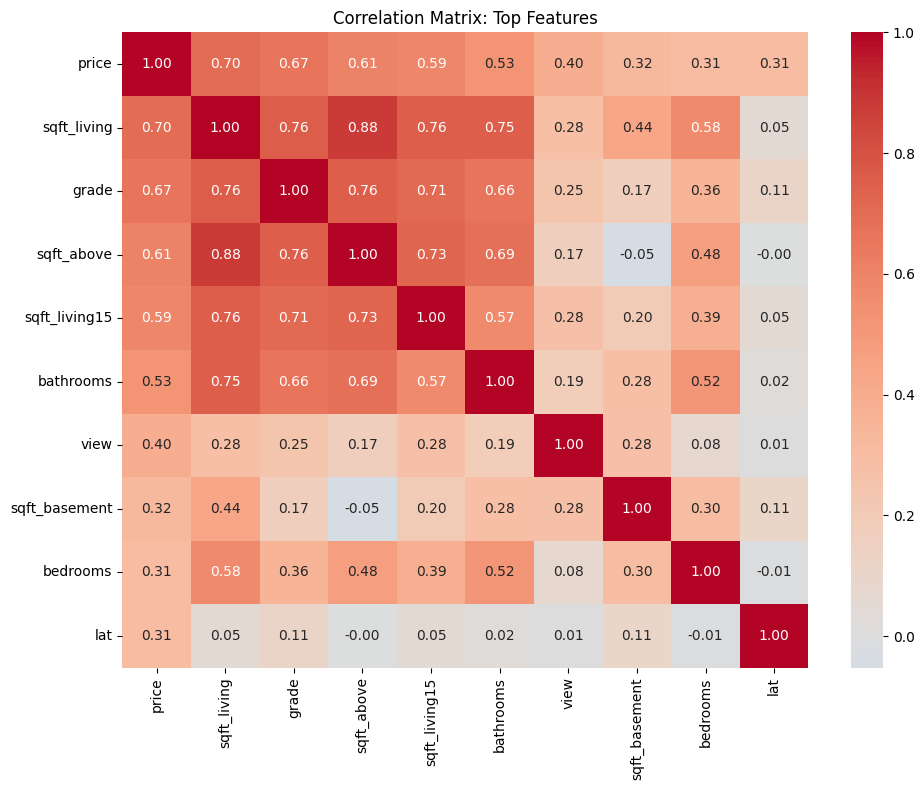

In [ ]:
# Correlation mapa de calor for top característicastop_features = correlations.abs().nlargest(10).index.tolist()plt.figure(figsize=(10, 8))sns.heatmap(df[top_features].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")plt.title("Correlation Matrix: Top Features")plt.tight_layout()plt.show()

**Correlaciones clave**:
- `sqft_living` (0.70) — predictor más fuerte
- `grade` (0.67) — calidad de construcción
- `sqft_above` (0.61) — área sobre el nivel del suelo
- Alta multicolinealidad entre las características de superficie (esperado)

## 7. Análisis Geográfico

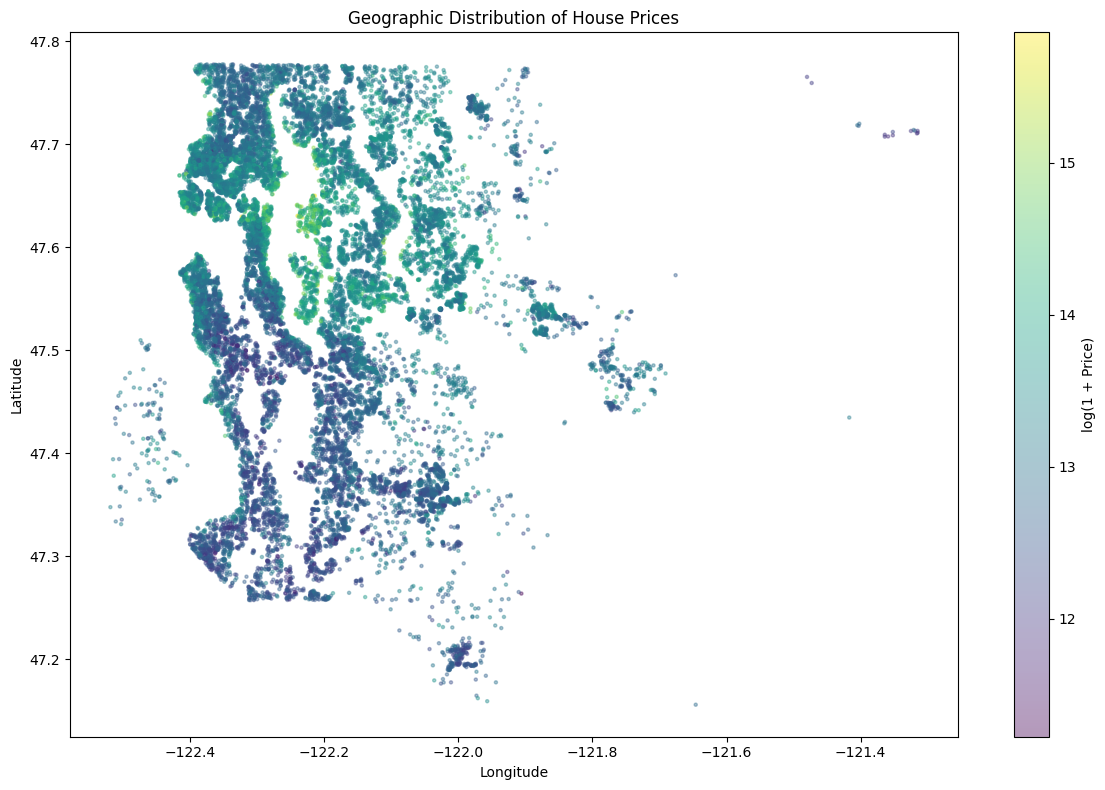

In [ ]:
plt.figure(figsize=(12, 8))scatter = plt.scatter(    df["long"], df["lat"],    c=np.log1p(df["price"]),    cmap="viridis",    alpha=0.4,    s=5)plt.colorbar(scatter, label="log(1 + Price)")plt.xlabel("Longitude")plt.ylabel("Latitude")plt.title("Geographic Distribution of House Prices")plt.tight_layout()plt.show()

**Hallazgo**: Patrones claros de precios geográficos. Ciertas áreas (frente al agua, centros urbanos) tienen precios consistentemente más altos. El agrupamiento geográfico podría capturar estos patrones.

## Relaciones entre Características y Objetivo
Visualicemos cómo las características más predictivas se relacionan con el precio.

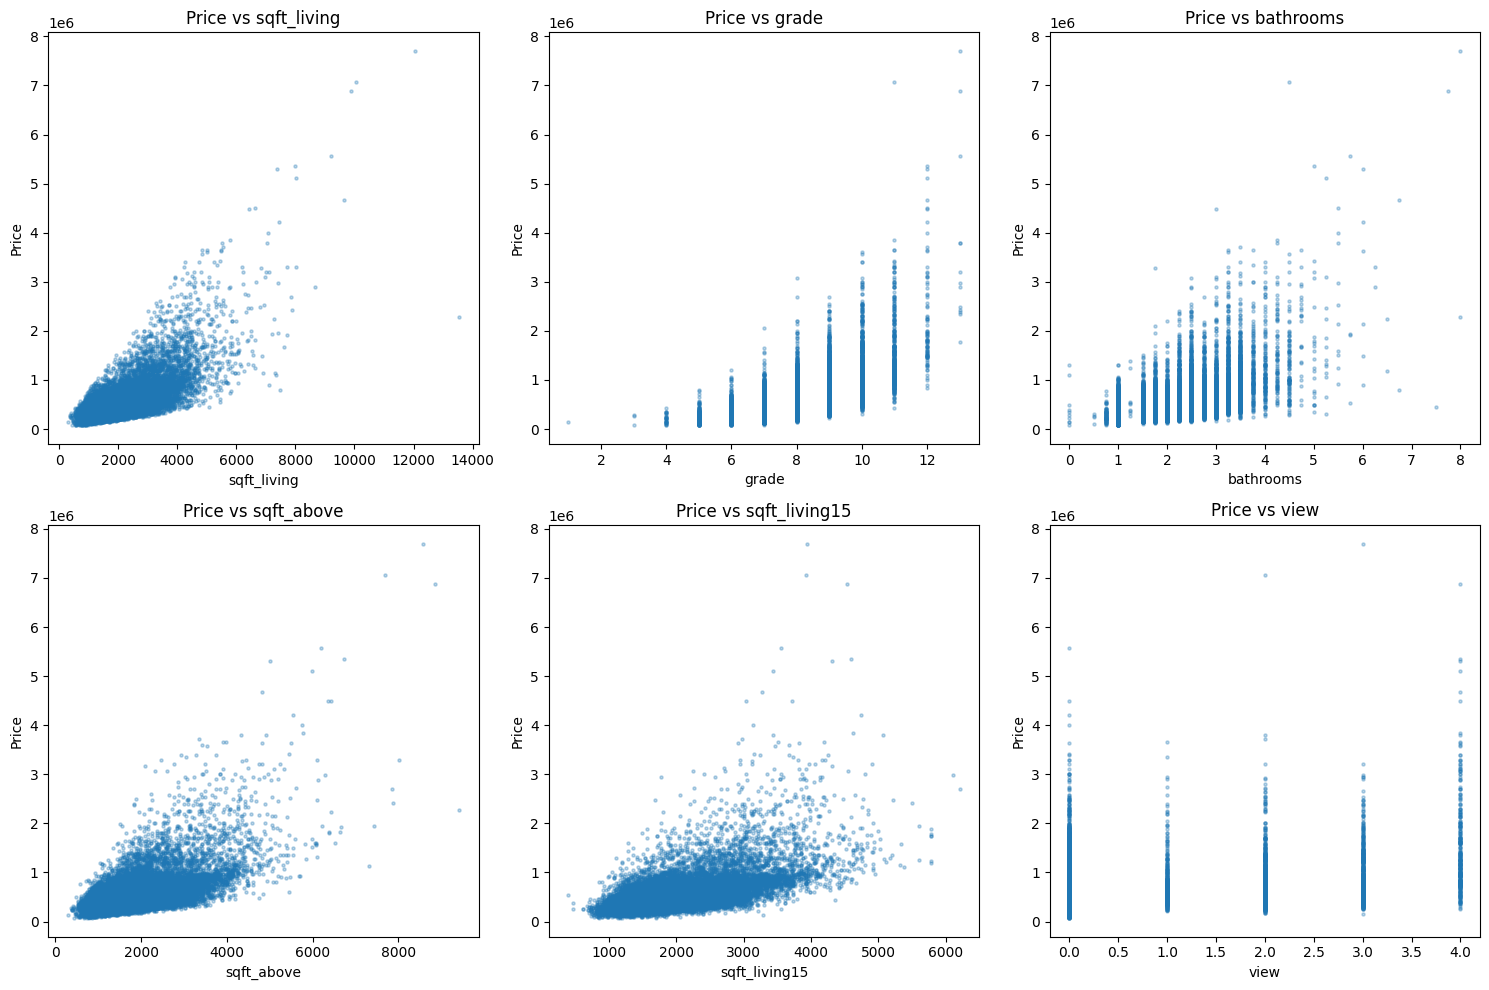

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))features_to_plot = ["sqft_living", "grade", "bathrooms", "sqft_above", "sqft_living15", "view"]for ax, feat in zip(axes.flatten(), features_to_plot):    ax.scatter(df[feat], df["price"], alpha=0.3, s=5)    ax.set_xlabel(feat)    ax.set_ylabel("Price")    ax.set_title(f"Price vs {feat}")plt.tight_layout()plt.show()

**Observaciones:**
- `sqft_living`: Relación positiva clara pero con varianza creciente en valores altos (heterocedasticidad)
- `grade`: Patrón escalonado fuerte — el grado es altamente predictivo
- `bathrooms`: Relación positiva con algunos valores atípicos
- `view`: Calificaciones de vista más altas asociadas a precios más altos, pero la mayoría de propiedades tienen view=0

## Posible Ingeniería de Características
Basándonos en el conocimiento del dominio y los hallazgos del EDA, exploramos algunas características derivadas potenciales.

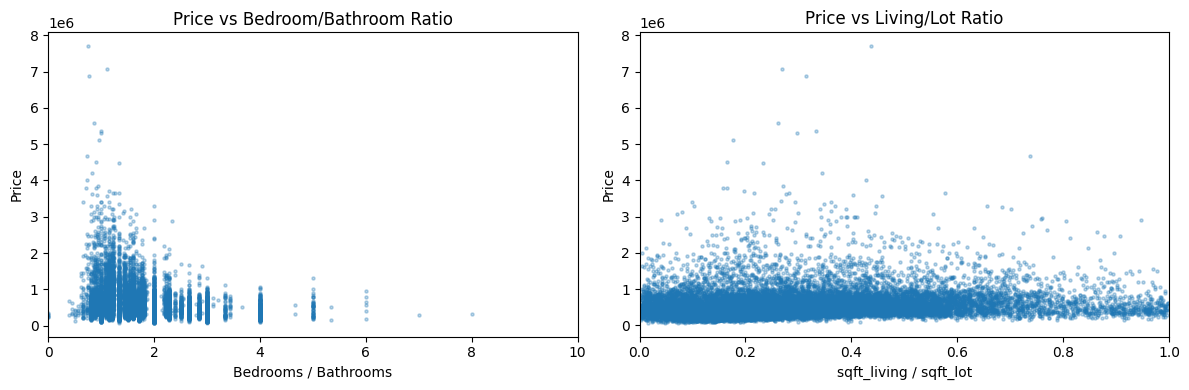

Correlation of bed/bath ratio with price: -0.249
Correlation of living/lot ratio with price: 0.123


In [ ]:
# Explore potential ratio característicasfig, axes = plt.subplots(1, 2, figsize=(12, 4))# Bedroom to bathroom ratiobed_bath_ratio = df["bedrooms"] / df["bathrooms"].replace(0, np.nan)axes[0].scatter(bed_bath_ratio, df["price"], alpha=0.3, s=5)axes[0].set_xlabel("Bedrooms / Bathrooms")axes[0].set_ylabel("Price")axes[0].set_title("Price vs Bedroom/Bathroom Ratio")axes[0].set_xlim(0, 10)  # Limit x-axis for better visualization# Living to lot ratioliving_lot_ratio = df["sqft_living"] / df["sqft_lot"].replace(0, np.nan)axes[1].scatter(living_lot_ratio, df["price"], alpha=0.3, s=5)axes[1].set_xlabel("sqft_living / sqft_lot")axes[1].set_ylabel("Price")axes[1].set_title("Price vs Living/Lot Ratio")axes[1].set_xlim(0, 1)  # Most valores are below 1plt.tight_layout()plt.show()print(f"Correlation of bed/bath ratio with price: {bed_bath_ratio.corr(df['price']):.3f}")print(f"Correlation of living/lot ratio with price: {living_lot_ratio.corr(df['price']):.3f}")

**Observaciones sobre las características de razón:**
- La razón habitaciones/baños muestra algún patrón pero correlación débil
- La razón habitables/lote podría capturar información sobre la densidad de la propiedad

Estas razones pueden proporcionar valor marginal y vale la pena incluirlas en el pipeline de preprocesamiento.

## Resumen: Hallazgos del EDA

### Calidad de los Datos
- **Sin valores faltantes** en el conjunto de datos
- **Columna `date`**: Formato de cadena, se pueden extraer año/mes para características temporales
- **`zipcode`**: Numérico pero categórico por naturaleza; la latitud/longitud proporciona mejor información geográfica

### Variable Objetivo
- **Price está sesgado a la derecha** (asimetría > 2)
- La transformación logarítmica normaliza la distribución
- Considera si predecir log(price) e invertir la transformación, o usar modelos robustos ante la asimetría

### Transformaciones de Características
- **Aplicar transformación logarítmica a**: `sqft_living`, `sqft_lot`, `sqft_above`, `sqft_basement`, `sqft_living15`, `sqft_lot15`
- **Escalado estándar** para otras características numéricas

### Ingeniería de Características
- **Agrupamiento geográfico**: Usar K-means en (lat, long) para capturar efectos de vecindario
- **Características de razón**: razón habitaciones/baños, razón habitables/lote pueden añadir valor
- **Características temporales**: Extraer año y mes de venta de la fecha

### Consideraciones para la Selección de Modelos
- Relaciones lineales fuertes con algunas características → Los modelos lineales pueden funcionar como base
- Patrones geográficos complejos → Los modelos basados en árboles (random forest, gradient boosting) probablemente rindan mejor
- Multicolinealidad presente → Menos preocupante para modelos basados en árboles

### Características a Eliminar
- `id`: No predictivo
- `date`: Reemplazar con año/mes extraídos
- `zipcode`: Redundante con coordenadas lat/long

### Patrones Temporales
- Los precios varían con el tiempo
- **Crítico**: Requiere división temporal entrenamiento/prueba
- Ver `p3-03-temporal_leakage.ipynb`

### IDs de Propiedades Repetidos
- ~0.85% de los registros tienen IDs repetidos
- Son transacciones de reventa válidas
- Ver `p3-02-repeated_ids.ipynb`